In [3]:
# ============================================================
# NOTEBOOK 2 — PREPROCESSING
# Sliding window segmentation + normalization + train/test split
# ============================================================

# Mount Drive and reload master arrays
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import os

save_dir = '/content/drive/MyDrive/DL_Project_Gait/data/processed'

print("Loading master arrays...")
X_all = np.load(f'{save_dir}/X_all.npy')
y_all = np.load(f'{save_dir}/y_all.npy')
p_all = np.load(f'{save_dir}/p_all.npy')

print(f"✓ X_all shape: {X_all.shape}")
print(f"✓ y_all shape: {y_all.shape}")
print(f"✓ p_all shape: {p_all.shape}")
print(f"✓ Participants: {sorted(np.unique(p_all))}")
print(f"✓ Activities:   {sorted(np.unique(y_all))}")

Mounted at /content/drive
Loading master arrays...
✓ X_all shape: (1137986, 36)
✓ y_all shape: (1137986,)
✓ p_all shape: (1137986,)
✓ Participants: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]
✓ Activities:   [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11)]


In [4]:
# ============================================================
# SUBJECT-LEVEL SPLIT — Critical for valid evaluation
# ============================================================
# Train: participants 1,2,5,6,8,10,11,13,14,15  (10 subjects = ~55%)
# Val:   participants 16,17,18                   (3 subjects  = ~17%)
# Test:  participants 3,4,7,9,12                 (5 subjects  = ~28%)
# ============================================================

TRAIN_PARTICIPANTS = [1, 2, 5, 6, 8, 10, 11, 13, 14, 15]
VAL_PARTICIPANTS   = [16, 17, 18]
TEST_PARTICIPANTS  = [3, 4, 7, 9, 12]

# Create boolean masks
train_mask = np.isin(p_all, TRAIN_PARTICIPANTS)
val_mask   = np.isin(p_all, VAL_PARTICIPANTS)
test_mask  = np.isin(p_all, TEST_PARTICIPANTS)

# Split raw data by participant
X_train_raw = X_all[train_mask]
y_train_raw = y_all[train_mask]

X_val_raw   = X_all[val_mask]
y_val_raw   = y_all[val_mask]

X_test_raw  = X_all[test_mask]
y_test_raw  = y_all[test_mask]

print("Subject-level split:")
print(f"  Train: {X_train_raw.shape[0]:>8,} samples | participants {TRAIN_PARTICIPANTS}")
print(f"  Val:   {X_val_raw.shape[0]:>8,} samples | participants {VAL_PARTICIPANTS}")
print(f"  Test:  {X_test_raw.shape[0]:>8,} samples | participants {TEST_PARTICIPANTS}")
print(f"  Total: {len(X_all):>8,} samples")
print(f"\nNo data leakage: participants never appear in more than one split ✓")

Subject-level split:
  Train:  657,658 samples | participants [1, 2, 5, 6, 8, 10, 11, 13, 14, 15]
  Val:    185,410 samples | participants [16, 17, 18]
  Test:   294,918 samples | participants [3, 4, 7, 9, 12]
  Total: 1,137,986 samples

No data leakage: participants never appear in more than one split ✓


In [5]:
from sklearn.preprocessing import StandardScaler

# ============================================================
# NORMALIZATION — Fit ONLY on train, transform all splits
# This prevents data leakage from val/test into training stats
# ============================================================

print("Fitting StandardScaler on training data only...")
scaler = StandardScaler()

# Fit on train, transform all
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled   = scaler.transform(X_val_raw)
X_test_scaled  = scaler.transform(X_test_raw)

print(f"✓ Train mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"✓ Train std  (should be ~1): {X_train_scaled.std():.4f}")
print(f"✓ Val mean:  {X_val_scaled.mean():.4f}")
print(f"✓ Test mean: {X_test_scaled.mean():.4f}")

# Save scaler for inference later
import pickle
scaler_path = '/content/drive/MyDrive/DL_Project_Gait/models/scaler.pkl'
os.makedirs('/content/drive/MyDrive/DL_Project_Gait/models/', exist_ok=True)
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"\n✓ Scaler saved to {scaler_path}")

Fitting StandardScaler on training data only...
✓ Train mean (should be ~0): 0.0000
✓ Train std  (should be ~1): 1.0000
✓ Val mean:  0.0063
✓ Test mean: -0.0036

✓ Scaler saved to /content/drive/MyDrive/DL_Project_Gait/models/scaler.pkl


In [6]:
# ============================================================
# SLIDING WINDOW SEGMENTATION
# Window size: 128 samples @ ~60Hz = ~2.1 seconds per window
# Overlap: 50% → step size = 64 samples
# Label: majority vote within the window
# ============================================================

WINDOW_SIZE = 128
STEP_SIZE   = 64   # 50% overlap

def sliding_window(X, y, window_size=128, step_size=64):
    """
    Apply sliding window to continuous sensor data.

    Args:
        X: sensor data (n_samples, n_features)
        y: labels (n_samples,)
        window_size: number of timesteps per window
        step_size: stride between windows

    Returns:
        X_windows: (n_windows, window_size, n_features)
        y_windows: (n_windows,) — majority label in each window
    """
    X_windows, y_windows = [], []

    for start in range(0, len(X) - window_size, step_size):
        end = start + window_size
        window_data   = X[start:end]          # (window_size, n_features)
        window_labels = y[start:end]          # (window_size,)

        # Majority vote for window label
        values, counts = np.unique(window_labels, return_counts=True)
        majority_label = values[np.argmax(counts)]

        X_windows.append(window_data)
        y_windows.append(majority_label)

    return np.array(X_windows, dtype=np.float32), np.array(y_windows, dtype=np.int64)

print("Applying sliding window segmentation...")
print(f"  Window size: {WINDOW_SIZE} samples (~{WINDOW_SIZE/60:.1f} seconds)")
print(f"  Step size:   {STEP_SIZE} samples (50% overlap)")
print()

print("Processing train split...")
X_train, y_train = sliding_window(X_train_scaled, y_train_raw, WINDOW_SIZE, STEP_SIZE)
print(f"  ✓ X_train: {X_train.shape}")

print("Processing val split...")
X_val, y_val = sliding_window(X_val_scaled, y_val_raw, WINDOW_SIZE, STEP_SIZE)
print(f"  ✓ X_val:   {X_val.shape}")

print("Processing test split...")
X_test, y_test = sliding_window(X_test_scaled, y_test_raw, WINDOW_SIZE, STEP_SIZE)
print(f"  ✓ X_test:  {X_test.shape}")

print(f"\nTotal windows created: {len(X_train)+len(X_val)+len(X_test):,}")

Applying sliding window segmentation...
  Window size: 128 samples (~2.1 seconds)
  Step size:   64 samples (50% overlap)

Processing train split...
  ✓ X_train: (10274, 128, 36)
Processing val split...
  ✓ X_val:   (2896, 128, 36)
Processing test split...
  ✓ X_test:  (4607, 128, 36)

Total windows created: 17,777


Label mapping:
   1 (walking             ) → class 0
   2 (running             ) → class 1
   3 (going_up            ) → class 2
   4 (going_down          ) → class 3
   5 (sitting             ) → class 4
   6 (sitting_down        ) → class 5
   7 (standing_up         ) → class 6
   8 (standing            ) → class 7
  10 (up_by_elevator      ) → class 8
  11 (down_by_elevator    ) → class 9

Total number of classes: 10


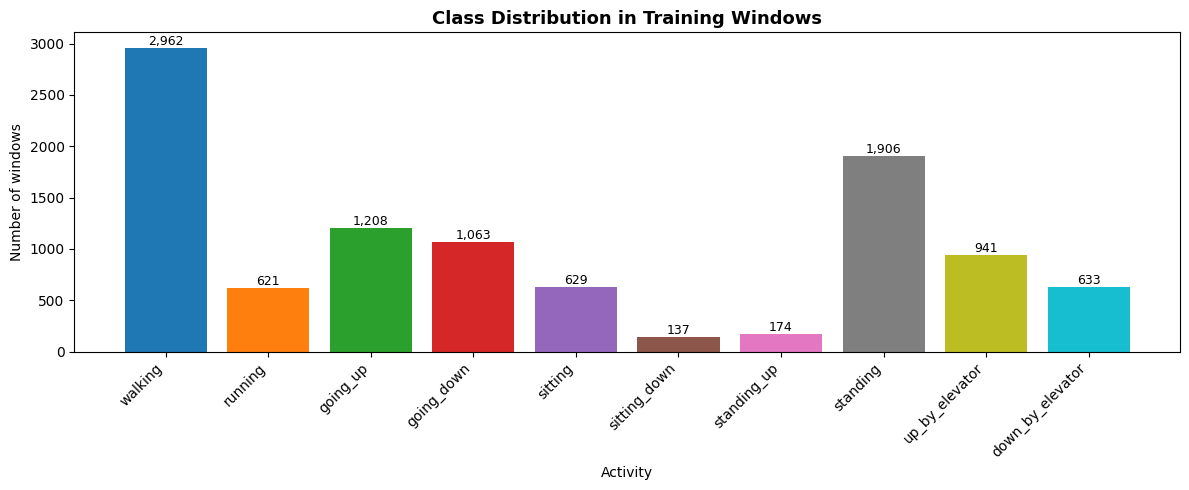


Class weights (for handling imbalance in training):
  Class 0 (walking             ): weight = 0.347
  Class 1 (running             ): weight = 1.654
  Class 2 (going_up            ): weight = 0.850
  Class 3 (going_down          ): weight = 0.967
  Class 4 (sitting             ): weight = 1.633
  Class 5 (sitting_down        ): weight = 7.499
  Class 6 (standing_up         ): weight = 5.905
  Class 7 (standing            ): weight = 0.539
  Class 8 (up_by_elevator      ): weight = 1.092
  Class 9 (down_by_elevator    ): weight = 1.623


In [7]:
# ============================================================
# REMAP LABELS to 0-based for PyTorch
# Original: 1,2,3,4,5,6,7,8,10,11
# Remapped: 0,1,2,3,4,5,6,7,8,9
# ============================================================

unique_labels = sorted(np.unique(y_all))
label_to_idx  = {label: idx for idx, label in enumerate(unique_labels)}
idx_to_label  = {idx: label for label, idx in label_to_idx.items()}

activity_names = {
    1: 'walking', 2: 'running', 3: 'going_up', 4: 'going_down',
    5: 'sitting', 6: 'sitting_down', 7: 'standing_up', 8: 'standing',
    10: 'up_by_elevator', 11: 'down_by_elevator'
}

print("Label mapping:")
for orig, new in label_to_idx.items():
    print(f"  {orig:2d} ({activity_names.get(orig,'?'):20s}) → class {new}")

# Apply remapping
y_train_mapped = np.array([label_to_idx[l] for l in y_train], dtype=np.int64)
y_val_mapped   = np.array([label_to_idx[l] for l in y_val],   dtype=np.int64)
y_test_mapped  = np.array([label_to_idx[l] for l in y_test],  dtype=np.int64)

N_CLASSES = len(unique_labels)
print(f"\nTotal number of classes: {N_CLASSES}")

# Class balance in train set
import matplotlib.pyplot as plt

unique_train, counts_train = np.unique(y_train_mapped, return_counts=True)
labels_names = [activity_names.get(idx_to_label[i], str(i)) for i in unique_train]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels_names, counts_train,
              color=plt.cm.tab10(np.linspace(0, 1, len(unique_train))))
ax.set_title('Class Distribution in Training Windows', fontsize=13, fontweight='bold')
ax.set_xlabel('Activity')
ax.set_ylabel('Number of windows')
plt.xticks(rotation=45, ha='right')
for bar, count in zip(bars, counts_train):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{count:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DL_Project_Gait/results/train_class_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Compute class weights for handling imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced',
                                      classes=np.unique(y_train_mapped),
                                      y=y_train_mapped)
print(f"\nClass weights (for handling imbalance in training):")
for i, (name, w) in enumerate(zip(labels_names, class_weights)):
    print(f"  Class {i} ({name:20s}): weight = {w:.3f}")

In [8]:
# Save everything for use in training notebooks
print("Saving preprocessed windows to Drive...")

np.save(f'{save_dir}/X_train.npy', X_train)
np.save(f'{save_dir}/y_train.npy', y_train_mapped)
np.save(f'{save_dir}/X_val.npy',   X_val)
np.save(f'{save_dir}/y_val.npy',   y_val_mapped)
np.save(f'{save_dir}/X_test.npy',  X_test)
np.save(f'{save_dir}/y_test.npy',  y_test_mapped)

# Save class weights and label mapping
np.save(f'{save_dir}/class_weights.npy', class_weights)
np.save(f'{save_dir}/label_mapping.npy',
        np.array([[k,v] for k,v in label_to_idx.items()]))

print(f"✓ All files saved to {save_dir}")
print(f"\nFinal dataset summary:")
print(f"  X_train: {X_train.shape}  y_train: {y_train_mapped.shape}")
print(f"  X_val:   {X_val.shape}    y_val:   {y_val_mapped.shape}")
print(f"  X_test:  {X_test.shape}   y_test:  {y_test_mapped.shape}")
print(f"  N_CLASSES: {N_CLASSES}")
print(f"  Window size: {WINDOW_SIZE} timesteps")
print(f"  N_FEATURES: {X_train.shape[2]} sensor channels")
print(f"\n✓ Notebook 2 complete! Ready for model training.")

Saving preprocessed windows to Drive...
✓ All files saved to /content/drive/MyDrive/DL_Project_Gait/data/processed

Final dataset summary:
  X_train: (10274, 128, 36)  y_train: (10274,)
  X_val:   (2896, 128, 36)    y_val:   (2896,)
  X_test:  (4607, 128, 36)   y_test:  (4607,)
  N_CLASSES: 10
  Window size: 128 timesteps
  N_FEATURES: 36 sensor channels

✓ Notebook 2 complete! Ready for model training.
